In [1]:
# Statistics

In [2]:
# Import relevant Python packages:
import xarray as xr
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# Following pip installation as shown on the LT Toolbox github:
import lt_toolbox as ltt
import gsw.density as density

# Searching the OceanDataCatalog dataset

from OceanDataStore import OceanDataCatalog

catalog = OceanDataCatalog(catalog_name="noc-model-stac")

#catalog.available_collections

#Era 5 probs the best here

#Searching the ERA5 collection
#catalog.search(collection='noc-npd-era5')
#catalog.available_items

t1 = catalog.open_dataset(id= 'noc-npd-era5/npd-eorca1-era5v1/gn/T1y',
                          start_datetime='2000-01',
                          end_datetime='2010-12',
                          )

#t1


d1 = catalog.open_dataset(id= 'noc-npd-era5/npd-eorca1-era5v1/gn/domain/domain_cfg',
                          )

d1

  2026-04-10T15:54:56.281002Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /root/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66

  2026-04-10T15:55:00.633783Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error

<xarray.Dataset> Size: 710MB
Dimensions:       (y: 331, x: 360, nav_lev: 75)
Coordinates:
  * y             (y) int64 3kB 0 1 2 3 4 5 6 7 ... 324 325 326 327 328 329 330
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * nav_lev       (nav_lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
Data variables: (12/49)
    bathy_metry   (y, x) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    atlmsk        (y, x) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1t           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e3f_0         (nav_lev, y, x) float64 71MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    e1f           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1u           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    ...            ...
    vmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    vmaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    mbathy        (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    tmaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    umaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    top_level     (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
Attributes:
    CfgName:    UNKNOWN
    CfgIndex:   -999
    Iperio:     1
    Jperio:     0
    NFold:      1
    NFtype:     F
    VertCoord:  zps
    IsfCav:     0
    file_name:  mesh_mask.nc
    TimeStamp:  01/03/2025 22:19:49 -0000

In [4]:
# Creating monthly dataframes (120)

import polars as pl
import lt_toolbox as ltt
from pathlib import Path

lon_mdl = t1.nav_lon.values
lat_mdl = t1.nav_lat.values
depth_mdl = t1.deptht.values

traj_geo_all = {}

for year in range(1990, 2000):
    for month in range(1, 13):
        mm = f"{month:02d}"
        key = f"{year}_{mm}"
        
        traj_filepath = f"/dssgfs01/scratch/emdh1n25/project_1m_RAPID/eORCA1/eORCA1_output/parquet/ORCA1_NPD_{mm}_{year}_25_1m_run.parquet"
        
        if not Path(traj_filepath).exists():
            print(f"Missing {key}, skipping")
            continue

        print(f"Processing {key}...")

        # Load
        dataset = pl.read_parquet(traj_filepath, use_pyarrow=True)

        # TrajFrame
        traj = ltt.TrajFrame(source=dataset, condense=True)

        # Time conversion 
        traj_geo = traj.use_datetime(start_date=f'{year}-01-01', unit='s')

        # Save original grid indices before transform
        x_orig = traj_geo.data["x"]
        y_orig = traj_geo.data["y"]
        z_orig = traj_geo.data["z"]

        # Coordinate transform
        traj_geo_interp = traj_geo.transform_trajectory_coords(
            lon=lon_mdl,
            lat=lat_mdl,
            depth=depth_mdl
        )

        # Re-add original grid indices alongside transformed coords
        traj_geo_interp.data = traj_geo_interp.data.with_columns([
            x_orig.alias("x"),
            y_orig.alias("y"),
            z_orig.alias("z"),
        ]).select([
            "id",
            "x", "y", "z",
            pl.all().exclude(["id", "x", "y", "z"])
        ])

        # Store
        traj_geo_all[key] = traj_geo_interp

        # Free memory 
        del dataset, traj, traj_geo

print("All done.")

Processing 1990_01...
Processing 1990_02...
Processing 1990_03...
Processing 1990_04...
Processing 1990_05...
Processing 1990_06...
Processing 1990_07...
Processing 1990_08...
Processing 1990_09...
Processing 1990_10...
Processing 1990_11...
Processing 1990_12...
Processing 1991_01...
Processing 1991_02...
Processing 1991_03...
Processing 1991_04...
Processing 1991_05...
Processing 1991_06...
Processing 1991_07...
Processing 1991_08...
Processing 1991_09...
Processing 1991_10...
Processing 1991_11...
Processing 1991_12...
Processing 1992_01...
Processing 1992_02...
Processing 1992_03...
Processing 1992_04...
Processing 1992_05...
Processing 1992_06...
Processing 1992_07...
Processing 1992_08...
Processing 1992_09...
Processing 1992_10...
Processing 1992_11...
Processing 1992_12...
Processing 1993_01...
Processing 1993_02...
Processing 1993_03...
Processing 1993_04...
Processing 1993_05...
Processing 1993_06...
Processing 1993_07...
Processing 1993_08...
Processing 1993_09...
Processing

In [5]:
# Checking out an individual year

df = traj_geo_all["1990_01"].data

df["subvol"].list.first().sum()/1e6

df

id,x,y,z,lon,lat,depth,subvol,time,boxface,somxl010,hfds,thetao_con,so_abs
i64,list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[datetime[μs]],list[i64],list[f64],list[f64],list[f64],list[f64]
1,"[206.16, 206.15, … 287.08]","[229.0, 229.13, … 311.0]","[0.83, 1.0, … 33.94]","[-80.341999, -80.352155, … 30.876509]","[26.913236, 27.026828, … 76.252002]","[1.377339, 1.555855, … 299.115645]","[1489.79, 1489.79, … 1489.79]","[1990-01-01 00:00:00, 1990-01-02 05:32:52.160, … 1997-08-06 17:45:17.600]","[3, 5, … 3]","[29.82, 39.57, … 32.75]","[-87.57, -72.11, … -116.4]","[24.16, 23.55, … 1.16]","[36.29, 36.37, … 35.03]"
2,"[206.16, 206.12, … 258.25]","[229.0, 229.44, … 229.0]","[0.5, 1.0, … 29.02]","[-80.341999, -80.382524, … -28.249963]","[26.913236, 27.297691, … 26.953199]","[1.030808, 1.555855, … 180.934727]","[1489.79, 1489.79, … 1489.79]","[1990-01-01 00:00:00, 1990-01-05 18:20:03.150, … 1998-10-20 02:31:46.019999]","[3, 5, … 4]","[29.82, 40.42, … 65.27]","[-87.57, -74.84, … -162.25]","[24.16, 23.59, … 17.76]","[36.29, 36.37, … 36.32]"
3,"[206.16, 206.06, … 256.73]","[229.0, 229.88, … 229.0]","[0.16, 1.0, … 31.06]","[-80.341999, -80.443047, … -29.770128]","[26.913236, 27.682108, … 26.953166]","[0.673775, 1.555855, … 222.566141]","[1489.79, 1489.79, … 1489.79]","[1990-01-01 00:00:00, 1990-01-13 23:30:03.440, … 1998-01-04 15:08:25.460]","[3, 5, … 4]","[29.82, 42.6, … 67.9]","[-87.57, -81.81, … -30.04]","[24.16, 23.69, … 17.08]","[36.29, 36.34, … 36.32]"
4,"[206.5, 206.46, … 271.27]","[229.0, 229.13, … 229.0]","[0.83, 1.0, … 18.56]","[-80.002015, -80.04217, … -15.228497]","[26.913545, 27.027125, … 26.948756]","[1.377339, 1.555855, … 57.917469]","[1489.79, 1489.79, … 1489.79]","[1990-01-01 00:00:00, 1990-01-02 05:32:52.160, … 2010-08-02 17:11:28.420]","[3, 5, … 4]","[29.82, 39.57, … 19.64]","[-87.57, -72.11, … 19.53]","[24.16, 23.55, … 17.41]","[36.29, 36.37, … 35.77]"
5,"[206.5, 206.36, … 220.0]","[229.0, 229.44, … 286.1]","[0.5, 1.0, … 26.58]","[-80.002015, -80.142539, … -73.134042]","[26.913545, 27.297949, … 62.503289]","[1.030808, 1.555855, … 141.38747]","[1489.79, 1489.79, … 1489.79]","[1990-01-01 00:00:00, 1990-01-05 18:20:03.150, … 1997-11-20 21:31:50.030]","[3, 5, … 2]","[29.82, 40.42, … 47.51]","[-87.57, -74.84, … -31.53]","[24.16, 23.59, … 0.39]","[36.29, 36.37, … 33.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…
28417,"[269.91, 269.89]","[229.0, 229.0]","[61.75, 61.84]","[-16.58865, -16.608653]","[26.949624, 26.949635]","[3466.244385, 3483.236807]","[2414.93, 2414.93]","[1990-01-01 00:00:00, 1990-10-02 00:41:14.530]","[3, 4]","[62.76, 22.06]","[-94.83, 20.6]","[2.32, 2.33]","[35.1, 35.1]"
28418,"[269.91, 269.89]","[229.0, 229.0]","[61.58, 61.71]","[-16.58865, -16.608653]","[26.949624, 26.949635]","[3434.147588, 3458.692197]","[2414.93, 2414.93]","[1990-01-01 00:00:00, 1990-10-02 00:41:14.530]","[3, 4]","[62.76, 22.06]","[-94.83, 20.6]","[2.32, 2.33]","[35.1, 35.1]"
28419,"[269.91, 269.89]","[229.0, 229.0]","[61.41, 61.58]","[-16.58865, -16.608653]","[26.949624, 26.949635]","[3402.050791, 3434.147588]","[2414.93, 2414.93]","[1990-01-01 00:00:00, 1990-10-02 00:41:14.530]","[3, 4]","[62.76, 22.06]","[-94.83, 20.6]","[2.32, 2.33]","[35.1, 35.1]"


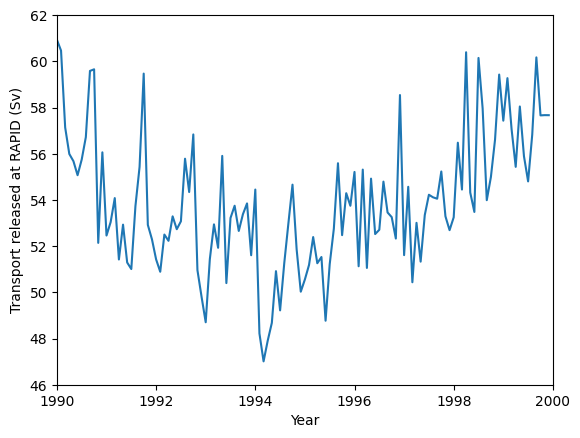

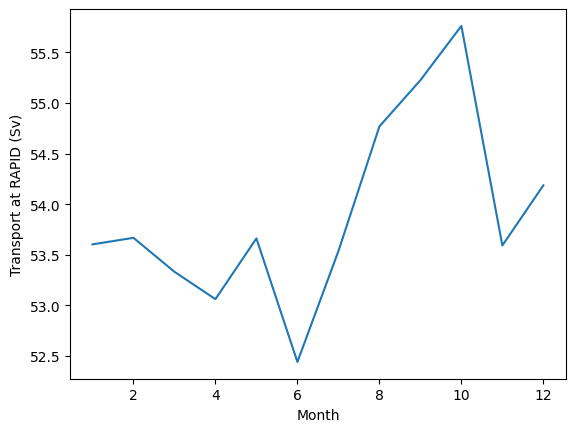

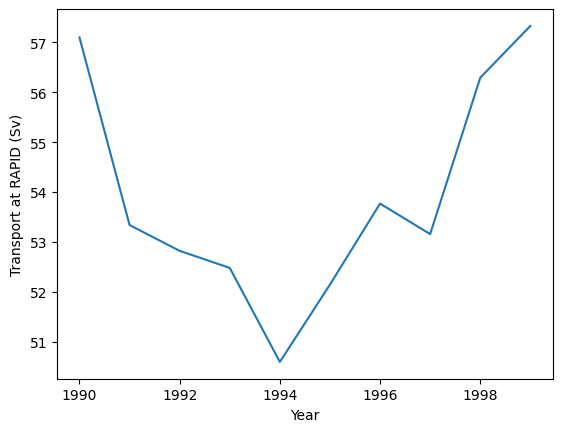

In [6]:
# RAPID
import polars as pl

results = {}

for year in range(1990, 2000):
    for month in range(1, 13):
        key = f"{year}_{month:02d}"
        if key in traj_geo_all:
            results[key] = traj_geo_all[key].data["subvol"].list.first().sum() / 1e6

results_df = pl.DataFrame({
    "year_month": list(results.keys()),
    "subvol_sum": list(results.values())
})

results_df = results_df.with_columns([
    pl.col("year_month").str.extract(r"(\d{4})_(\d{2})", 1).cast(pl.Int32).alias("year"),
    pl.col("year_month").str.extract(r"(\d{4})_(\d{2})", 2).cast(pl.Int32).alias("month"),
])

results_df_RAPID = results_df.with_columns([
    (pl.col("year") + (pl.col("month") -1) / 12).alias("time")
])

results_df_condensed_RAPID = results_df_RAPID['time', 'subvol_sum']

import matplotlib.pyplot as plt

plt.plot(results_df_condensed_RAPID["time"], results_df_condensed_RAPID["subvol_sum"])
plt.xlabel("Year")
plt.ylabel("Transport released at RAPID (Sv)")
plt.ylim(46, 62)
plt.xlim(1990, 2000)

plt.show()

import polars as pl
import matplotlib.pyplot as plt

monthly_mean_RAPID = (
    results_df_RAPID
    .group_by("month")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("month")
)

plt.plot(monthly_mean_RAPID["month"], monthly_mean_RAPID["subvol_mean"])
plt.xlabel("Month")
plt.ylabel("Transport at RAPID (Sv)")

plt.show()

import polars as pl
import matplotlib.pyplot as plt

annual_mean_RAPID = (
    results_df_RAPID
    .group_by("year")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("year")
)

plt.plot(annual_mean_RAPID["year"], annual_mean_RAPID["subvol_mean"])
plt.xlabel("Year")
plt.ylabel("Transport at RAPID (Sv)")

plt.show()

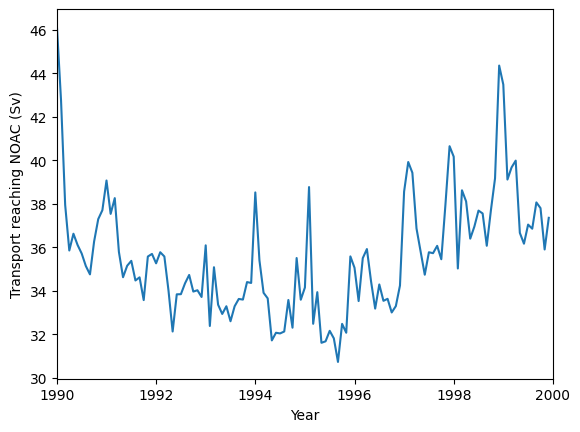

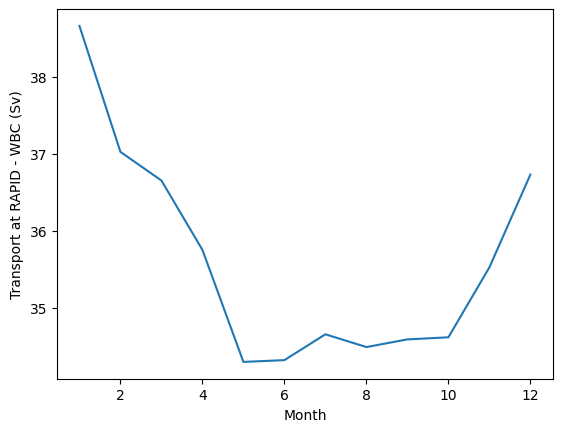

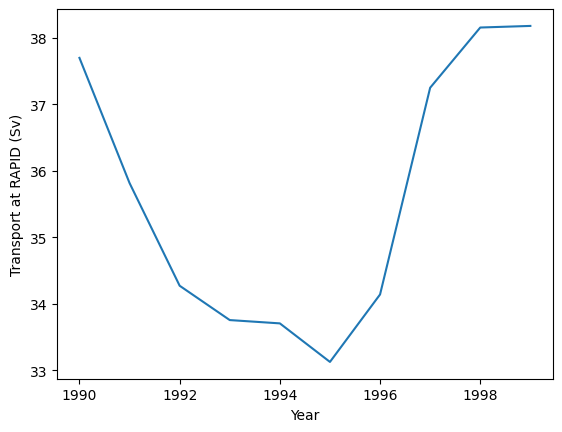

In [7]:
# RAPID - WBC
import polars as pl

results = {}

for year in range(1990, 2000):
    for month in range(1, 13):
        key = f"{year}_{month:02d}"
        if key in traj_geo_all:
            data = traj_geo_all[key].data.filter(
                pl.col("x").list.first() <= 213
            )
            results[key] = data["subvol"].list.first().sum() / 1e6

results_df = pl.DataFrame({
    "year_month": list(results.keys()),
    "subvol_sum": list(results.values())
})

results_df = results_df.with_columns([
    pl.col("year_month").str.extract(r"(\d{4})_(\d{2})", 1).cast(pl.Int32).alias("year"),
    pl.col("year_month").str.extract(r"(\d{4})_(\d{2})", 2).cast(pl.Int32).alias("month"),
])

results_df_WBC = results_df.with_columns([
    (pl.col("year") + (pl.col("month") - 1) / 12).alias("time")
])

results_df_condensed_WBC = results_df_WBC['time', 'subvol_sum']

import matplotlib.pyplot as plt

plt.plot(results_df_condensed_WBC["time"], results_df_condensed_WBC["subvol_sum"])
plt.xlabel("Year")
plt.ylabel("Transport reaching NOAC (Sv)")
#plt.ylim(7, 19)
plt.xlim(1990, 2000)

plt.show()

import polars as pl
import matplotlib.pyplot as plt

monthly_mean_WBC = (
    results_df_WBC
    .group_by("month")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("month")
)

plt.plot(monthly_mean_WBC["month"], monthly_mean_WBC["subvol_mean"])
plt.xlabel("Month")
plt.ylabel("Transport at RAPID - WBC (Sv)")

plt.show()

import polars as pl
import matplotlib.pyplot as plt

annual_mean_WBC = (
    results_df_WBC
    .group_by("year")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("year")
)

plt.plot(annual_mean_WBC["year"], annual_mean_WBC["subvol_mean"])
plt.xlabel("Year")
plt.ylabel("Transport at RAPID (Sv)")

plt.show()

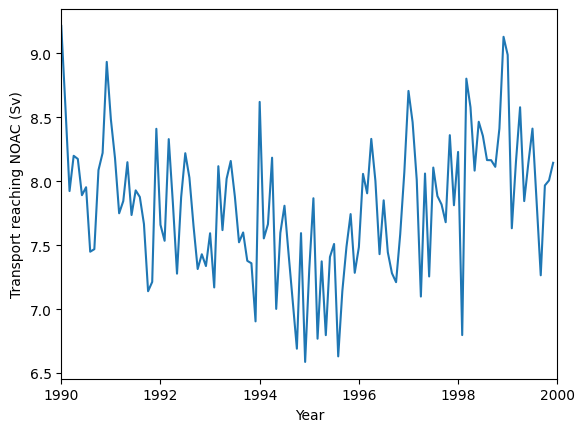

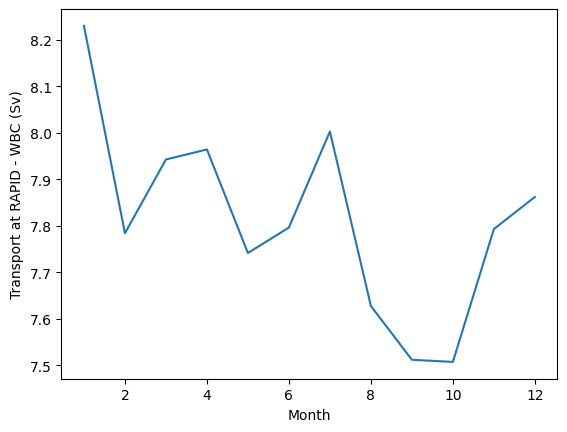

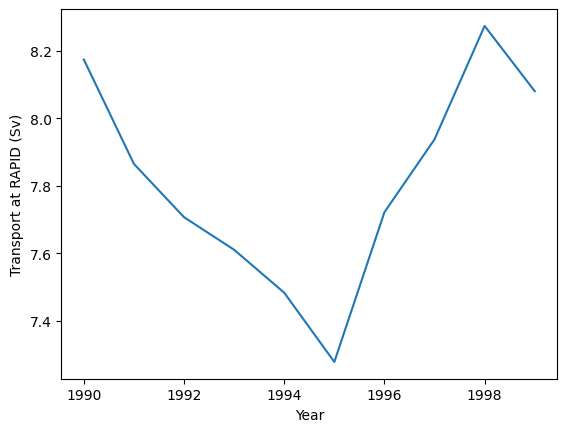

In [8]:
# RAPID - FC
import polars as pl

results = {}

for year in range(1990, 2000):
    for month in range(1, 13):
        key = f"{year}_{month:02d}"
        if key in traj_geo_all:
            data = traj_geo_all[key].data.filter(
                pl.col("x").list.first() <= 209
            )
            results[key] = data["subvol"].list.first().sum() / 1e6

results_df = pl.DataFrame({
    "year_month": list(results.keys()),
    "subvol_sum": list(results.values())
})

results_df = results_df.with_columns([
    pl.col("year_month").str.extract(r"(\d{4})_(\d{2})", 1).cast(pl.Int32).alias("year"),
    pl.col("year_month").str.extract(r"(\d{4})_(\d{2})", 2).cast(pl.Int32).alias("month"),
])

results_df_FC = results_df.with_columns([
    (pl.col("year") + (pl.col("month") - 1) / 12).alias("time")
])

results_df_condensed_FC = results_df_FC['time', 'subvol_sum']

import matplotlib.pyplot as plt

plt.plot(results_df_condensed_FC["time"], results_df_condensed_FC["subvol_sum"])
plt.xlabel("Year")
plt.ylabel("Transport reaching NOAC (Sv)")
#plt.ylim(7, 19)
plt.xlim(1990, 2000)

plt.show()

import polars as pl
import matplotlib.pyplot as plt

monthly_mean_FC = (
    results_df_FC
    .group_by("month")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("month")
)

plt.plot(monthly_mean_FC["month"], monthly_mean_FC["subvol_mean"])
plt.xlabel("Month")
plt.ylabel("Transport at RAPID - WBC (Sv)")

plt.show()

import polars as pl
import matplotlib.pyplot as plt

annual_mean_FC = (
    results_df_FC
    .group_by("year")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("year")
)

plt.plot(annual_mean_FC["year"], annual_mean_FC["subvol_mean"])
plt.xlabel("Year")
plt.ylabel("Transport at RAPID (Sv)")

plt.show()

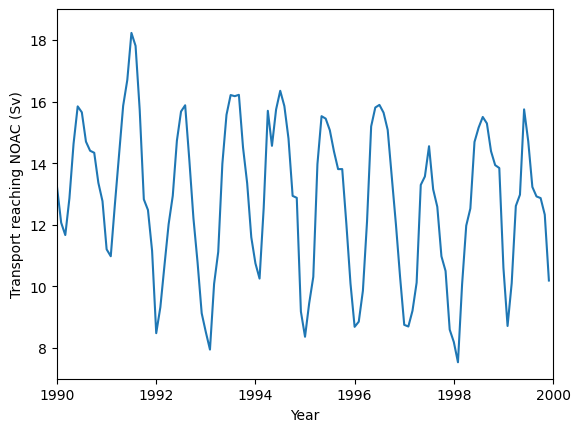

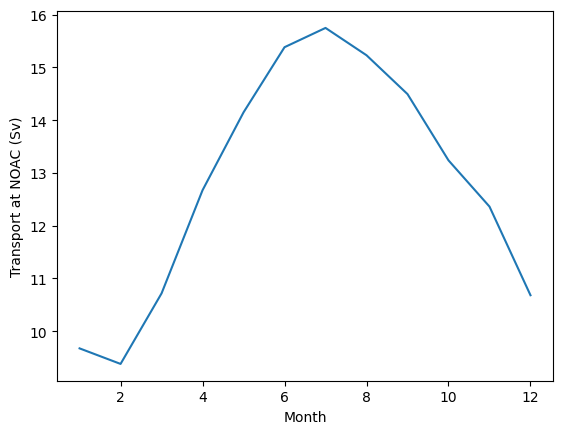

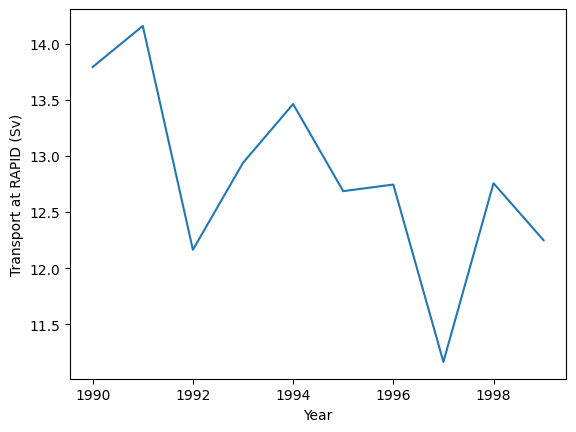

In [9]:
#NOAC

import polars as pl

results = {}

for year in range(1990, 2000):
    for month in range(1, 13):
        key = f"{year}_{month:02d}"
        if key in traj_geo_all:
            data = traj_geo_all[key].data.filter(
                pl.col("y").list.eval(pl.element() >= 257).list.any() # y within each list has to at be greater or equal to 257 to remain
            )
            results[key] = data["subvol"].list.first().sum() / 1e6

results_df = pl.DataFrame({
    "year_month": list(results.keys()),
    "subvol_sum": list(results.values())
})

results_df = results_df.with_columns([
    pl.col("year_month").str.extract(r"(\d{4})_(\d{2})", 1).cast(pl.Int32).alias("year"),
    pl.col("year_month").str.extract(r"(\d{4})_(\d{2})", 2).cast(pl.Int32).alias("month"),
])

results_df_NOAC = results_df.with_columns([
    (pl.col("year") + (pl.col("month") - 1) / 12).alias("time")
])

results_df_condensed_NOAC = results_df_NOAC['time', 'subvol_sum']

import matplotlib.pyplot as plt

plt.plot(results_df_condensed_NOAC["time"], results_df_condensed_NOAC["subvol_sum"])
plt.xlabel("Year")
plt.ylabel("Transport reaching NOAC (Sv)")
plt.ylim(7, 19)
plt.xlim(1990, 2000)

plt.show()

import polars as pl
import matplotlib.pyplot as plt

monthly_mean_NOAC = (
    results_df_NOAC
    .group_by("month")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("month")
)

plt.plot(monthly_mean_NOAC["month"], monthly_mean_NOAC["subvol_mean"])
plt.xlabel("Month")
plt.ylabel("Transport at NOAC (Sv)")

plt.show()

import polars as pl
import matplotlib.pyplot as plt

annual_mean_NOAC = (
    results_df_NOAC
    .group_by("year")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("year")
)

plt.plot(annual_mean_NOAC["year"], annual_mean_NOAC["subvol_mean"])
plt.xlabel("Year")
plt.ylabel("Transport at RAPID (Sv)")

plt.show()

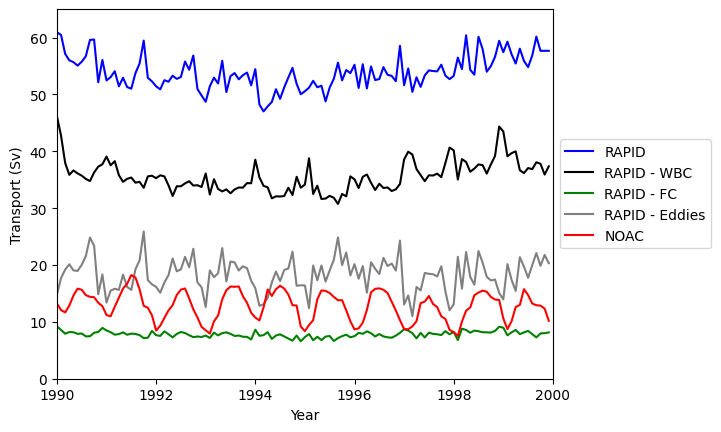

53.903163098166694 35.609541230999994 7.813232638583333 18.293621867166678 12.811090863916665
2.9624167260364955 2.7345960750403346 2.7345960750403346 2.90253851811384 2.513474583892021
Mean percentage of WBC flow reaching SPG: 35.97656813608127


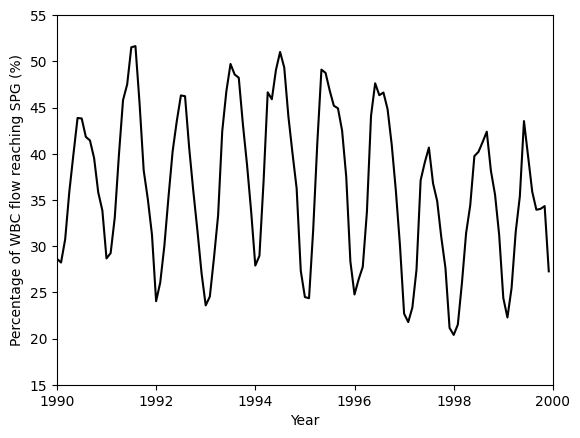

In [12]:
# Monthly timeseries

import matplotlib.pyplot as plt

plt.plot(results_df_condensed_RAPID["time"], results_df_condensed_RAPID["subvol_sum"], color = 'blue', label = "RAPID")
plt.plot(results_df_condensed_WBC["time"], results_df_condensed_WBC["subvol_sum"], color = 'black', label = "RAPID - WBC")
plt.plot(results_df_condensed_FC["time"], results_df_condensed_FC["subvol_sum"], color = 'green', label = "RAPID - FC")
plt.plot(results_df_condensed_RAPID["time"], (results_df_condensed_RAPID - results_df_condensed_WBC)["subvol_sum"], color = 'gray', label = "RAPID - Eddies")
plt.plot(results_df_condensed_NOAC["time"], results_df_condensed_NOAC["subvol_sum"], color = 'red', label = "NOAC")
plt.xlabel("Year")
plt.ylabel("Transport (Sv)")
plt.ylim(0, 65)
plt.xlim(1990, 2000)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

mean_RAPID = results_df_condensed_RAPID["subvol_sum"].mean()
mean_WBC   = results_df_condensed_WBC["subvol_sum"].mean()
mean_FC   = results_df_condensed_FC["subvol_sum"].mean()
mean_eddies = (results_df_condensed_RAPID["subvol_sum"] - results_df_condensed_WBC["subvol_sum"]).mean()
mean_NOAC  = results_df_condensed_NOAC["subvol_sum"].mean()

print(mean_RAPID, mean_WBC, mean_FC, mean_eddies, mean_NOAC)

std_RAPID = results_df_condensed_RAPID["subvol_sum"].std()
std_WBC   = results_df_condensed_WBC["subvol_sum"].std()
std_FC   = results_df_condensed_WBC["subvol_sum"].std()
std_eddies = (results_df_condensed_RAPID["subvol_sum"] - results_df_condensed_WBC["subvol_sum"]).std()
std_NOAC  = results_df_condensed_NOAC["subvol_sum"].std()

print(std_RAPID, std_WBC, std_FC, std_eddies, std_NOAC)

print("Mean percentage of WBC flow reaching SPG:", mean_NOAC/mean_WBC * 100)

plt.plot(results_df_condensed_RAPID["time"], results_df_condensed_NOAC["subvol_sum"]/results_df_condensed_WBC["subvol_sum"] * 100, 
         color = 'black')
plt.xlabel("Year")
plt.ylabel("Percentage of WBC flow reaching SPG (%)")
plt.ylim(15, 55)
plt.xlim(1990, 2000)

plt.show()

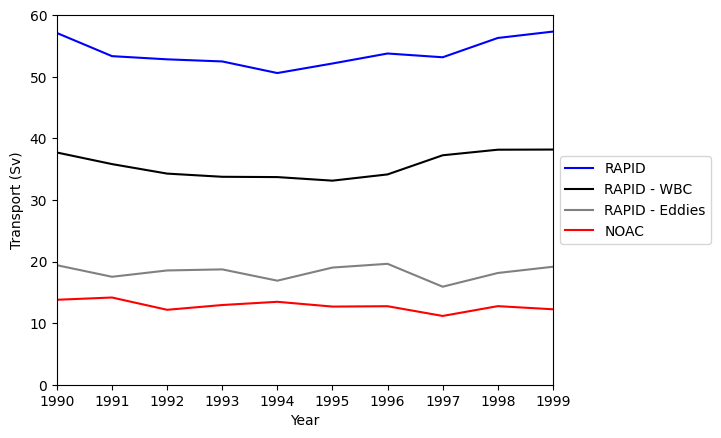

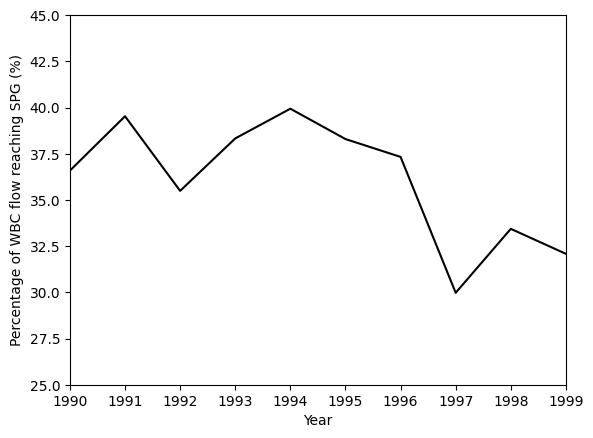

In [ ]:
# Annual mean timeseries

import polars as pl
import matplotlib.pyplot as plt

plt.plot(annual_mean_RAPID["year"], annual_mean_RAPID["subvol_mean"], label = "RAPID", color = 'blue')
plt.plot(annual_mean_WBC["year"], annual_mean_WBC["subvol_mean"], label = "RAPID - WBC", color = 'black')
plt.plot(annual_mean_FC["year"], annual_mean_FC["subvol_mean"], label = "RAPID - WBC", color = 'black')
plt.plot(annual_mean_NOAC["year"], (annual_mean_RAPID - annual_mean_WBC)["subvol_mean"], label = "RAPID - Eddies", color = 'gray')
plt.plot(annual_mean_NOAC["year"], annual_mean_NOAC["subvol_mean"], label = "NOAC", color = 'red')
plt.xlabel("Year")
plt.ylabel("Transport (Sv)")
plt.xlim(1990, 1999)
plt.ylim(0, 60)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

import matplotlib.pyplot as plt

plt.plot(annual_mean_RAPID["year"], annual_mean_NOAC["subvol_mean"]/annual_mean_WBC["subvol_mean"] * 100, 
         color = 'black')
plt.xlabel("Year")
plt.ylabel("Percentage of WBC flow reaching SPG (%)")
plt.ylim(25, 45)
plt.xlim(1990, 1999)

plt.show()

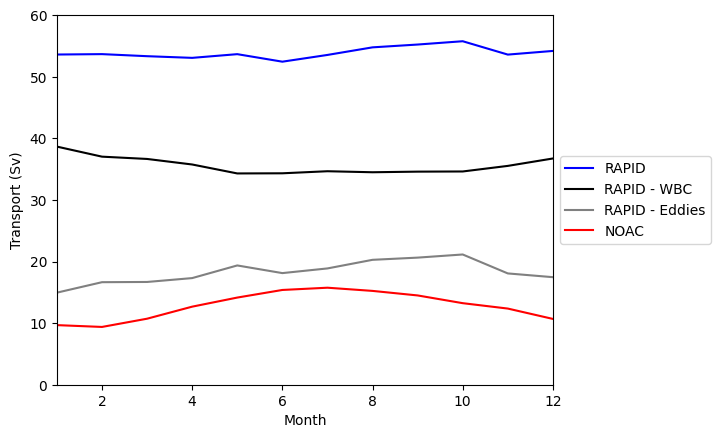

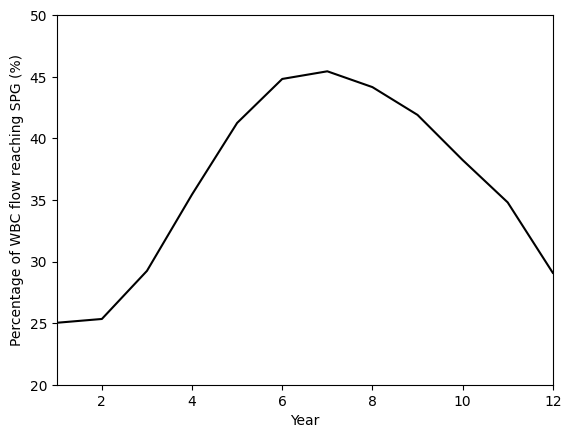

In [ ]:
# Mean month timeseries

import polars as pl
import matplotlib.pyplot as plt

plt.plot(monthly_mean_RAPID["month"], monthly_mean_RAPID["subvol_mean"], label = "RAPID", color = 'blue')
plt.plot(monthly_mean_WBC["month"], monthly_mean_WBC["subvol_mean"], label = "RAPID - WBC", color = 'black')
plt.plot(monthly_mean_FC["month"], monthly_mean_FC["subvol_mean"], label = "RAPID - WBC", color = 'green')
plt.plot(monthly_mean_WBC["month"], (monthly_mean_RAPID - monthly_mean_WBC)["subvol_mean"], label = "RAPID - Eddies", color = 'grey')
plt.plot(monthly_mean_NOAC["month"], monthly_mean_NOAC["subvol_mean"], label = "NOAC", color = 'red')
plt.xlabel("Month")
plt.ylabel("Transport (Sv)")
plt.xlim(1, 12)
plt.ylim(0, 60)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

import matplotlib.pyplot as plt

plt.plot(monthly_mean_RAPID["month"], monthly_mean_NOAC["subvol_mean"]/monthly_mean_WBC["subvol_mean"] * 100, 
         color = 'black')
plt.xlabel("Year")
plt.ylabel("Percentage of WBC flow reaching SPG (%)")
plt.ylim(20, 50)
plt.xlim(1, 12)

plt.show()

In [ ]:
# Time within domain for parcels as a histogram across all years


# Percentage of parcels remainung within domain - as a vlaue and by time of release

# Percebtage of parcels that leave through each opening

# Remember, only grid cell crossings are recorded

In [37]:
import numpy as np
import polars as pl

# Store filtered DataFrames for all months
boundary_trajs = {}

for year in range(1990, 2000):
    for month in range(1, 13):
        key = f"{year}_{month:02d}"
        print("Processing:", key)
        
        # Get trajectory data for this month
        df = traj_geo_all[key].data

        # Optional: compute trajectory length
        df = df.with_columns(
            (pl.col("time").list.last() - pl.col("time").list.first()).alias("length_time")
        )

        xs_list = df["x"].to_list()
        ys_list = df["y"].to_list()
        
        # Function to check if a trajectory hits a condition
        def hit_condition(xs, ys, x_cond=None, y_cond=None):
            xs = np.array(xs[1:])  # skip first point
            ys = np.array(ys[1:])
            x_mask = np.ones_like(xs, dtype=bool) if x_cond is None else x_cond(xs)
            y_mask = np.ones_like(ys, dtype=bool) if y_cond is None else y_cond(ys)
            return np.any(x_mask & y_mask)
        
        # Define boundary conditions
        conditions = [
            lambda xs, ys: hit_condition(xs, ys, lambda x: (x>=205)&(x<=281), lambda y: y==229),  # RAPID
            lambda xs, ys: hit_condition(xs, ys, lambda x: x==281, lambda y: (y>=229)&(y<=245)),  # Med
            lambda xs, ys: hit_condition(xs, ys, lambda x: (x>=220)&(x<=225), lambda y: y==290) or
                           hit_condition(xs, ys, lambda x: x==220, lambda y: (y>=270)&(y<=290)),  # HS
            lambda xs, ys: hit_condition(xs, ys, lambda x: (x>=225)&(x<=250), lambda y: y==290),  # DS
            lambda xs, ys: hit_condition(xs, ys, lambda x: (x>=250)&(x<=278), lambda y: y==311),  # FS
            lambda xs, ys: hit_condition(xs, ys, lambda x: (x>=278)&(x<=295), lambda y: y==311) or
                           hit_condition(xs, ys, lambda x: x==295, lambda y: (y>=300)&(y<=311))  # BS
        ]

        # Boolean: does each trajectory hit any boundary?
        hit_any = [any(cond(xs, ys) for cond in conditions) for xs, ys in zip(xs_list, ys_list)]

        # Keep only trajectories that hit at least one boundary
        df_boundaries = df.filter(pl.Series(hit_any))
        
        # Store filtered DataFrame
        boundary_trajs[key] = df_boundaries

        print(f"Original: {len(df)}, Boundary hits: {len(df_boundaries)}")

# Example: access boundary trajectories for January 1990
df_jan1990 = boundary_trajs["1990_01"]

Processing: 1990_01
Original: 28421, Boundary hits: 20764
Processing: 1990_02
Original: 28371, Boundary hits: 19813
Processing: 1990_03
Original: 27105, Boundary hits: 19052
Processing: 1990_04
Original: 26797, Boundary hits: 18809
Processing: 1990_05
Original: 26147, Boundary hits: 17444
Processing: 1990_06
Original: 26095, Boundary hits: 17386
Processing: 1990_07
Original: 26621, Boundary hits: 17746
Processing: 1990_08
Original: 26977, Boundary hits: 18162
Processing: 1990_09
Original: 28608, Boundary hits: 19203
Processing: 1990_10
Original: 28834, Boundary hits: 20093
Processing: 1990_11
Original: 24491, Boundary hits: 16595
Processing: 1990_12
Original: 26845, Boundary hits: 18726
Processing: 1991_01
Original: 24435, Boundary hits: 17112
Processing: 1991_02
Original: 24903, Boundary hits: 17499
Processing: 1991_03
Original: 25154, Boundary hits: 17356
Processing: 1991_04
Original: 24541, Boundary hits: 15648
Processing: 1991_05
Original: 25199, Boundary hits: 15791
Processing: 19

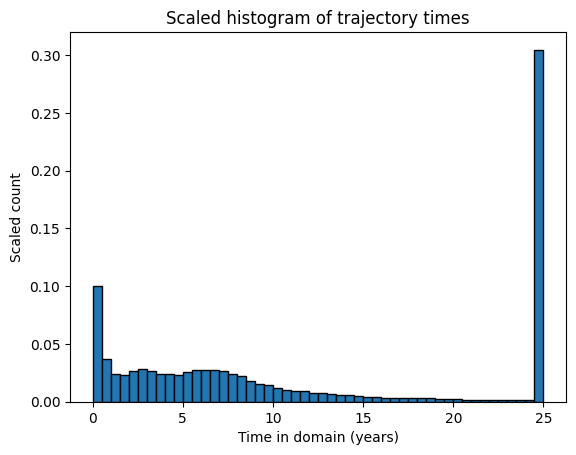

In [67]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Initialize list to collect all lengths and removed trajectories
all_lengths = []

# Loop over all years and months
for year in range(1990, 2000):
    for month in range(1, 13):
        key = f"{year}_{month:02d}"
        df = boundary_trajs[key]

        # Compute length_time in years
        df = df.with_columns(
            ((pl.col("time").list.last() - pl.col("time").list.first()).dt.total_seconds() / (86400*365.25))
            .alias("length_years")
        )

        df_pd = df.to_pandas()
        length_years = df_pd['length_years'].to_numpy()

        # Compute number of removed trajectories
        n_removed = len(traj_geo_all[key].data) - len(df)

        # Add real lengths + "fake" removed 25-year trajectories
        all_lengths.extend(length_years)
        all_lengths.extend([25]*n_removed)

# Convert to numpy array
all_lengths = np.array(all_lengths)

# Compute scaling factor
scale_factor = 0.30447404705082787 / 935421

# Make histogram with scaled heights
plt.hist(all_lengths, bins=50, weights=np.ones_like(all_lengths)*scale_factor, edgecolor='black')
plt.xlabel("Time in domain (years)")
plt.ylabel("Scaled count")
plt.title("Scaled histogram of trajectory times")
plt.show()

In [ ]:
df

# RAPID - y = 229, x between 205 and 281

# Med - x = 281, y between 229 and 245

# HS - x = 220, y between 270 and 290 or y = 290, x between 220 and 225

# DS - y = 290 x between 225 and 250

# FS - y = 312, x between 250 and 278

# BS - y = 312, x between 278 and 296 or = x = 296, y between 300 and 312

# Excluding the very first values (where the trajectories start), get code to find when x and y equal the above values - Count how many trajectories for each

id,x,y,z,lon,lat,depth,subvol,time,boxface,somxl010,hfds,thetao_con,so_abs,length_time
i64,list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[datetime[μs]],list[i64],list[f64],list[f64],list[f64],list[f64],duration[μs]
1,"[206.16, 206.15, … 287.08]","[229.0, 229.13, … 311.0]","[0.83, 1.0, … 33.94]","[-80.341999, -80.352155, … 30.876509]","[26.913236, 27.026828, … 76.252002]","[1.377339, 1.555855, … 299.115645]","[1489.79, 1489.79, … 1489.79]","[1990-01-01 00:00:00, 1990-01-02 05:32:52.160, … 1997-08-06 17:45:17.600]","[3, 5, … 3]","[29.82, 39.57, … 32.75]","[-87.57, -72.11, … -116.4]","[24.16, 23.55, … 1.16]","[36.29, 36.37, … 35.03]",2774d 17h 45m 17s 600ms
2,"[206.16, 206.12, … 258.25]","[229.0, 229.44, … 229.0]","[0.5, 1.0, … 29.02]","[-80.341999, -80.382524, … -28.249963]","[26.913236, 27.297691, … 26.953199]","[1.030808, 1.555855, … 180.934727]","[1489.79, 1489.79, … 1489.79]","[1990-01-01 00:00:00, 1990-01-05 18:20:03.150, … 1998-10-20 02:31:46.019999]","[3, 5, … 4]","[29.82, 40.42, … 65.27]","[-87.57, -74.84, … -162.25]","[24.16, 23.59, … 17.76]","[36.29, 36.37, … 36.32]",3214d 2h 31m 46s 19999µs
3,"[206.16, 206.06, … 256.73]","[229.0, 229.88, … 229.0]","[0.16, 1.0, … 31.06]","[-80.341999, -80.443047, … -29.770128]","[26.913236, 27.682108, … 26.953166]","[0.673775, 1.555855, … 222.566141]","[1489.79, 1489.79, … 1489.79]","[1990-01-01 00:00:00, 1990-01-13 23:30:03.440, … 1998-01-04 15:08:25.460]","[3, 5, … 4]","[29.82, 42.6, … 67.9]","[-87.57, -81.81, … -30.04]","[24.16, 23.69, … 17.08]","[36.29, 36.34, … 36.32]",2925d 15h 8m 25s 460ms
4,"[206.5, 206.46, … 271.27]","[229.0, 229.13, … 229.0]","[0.83, 1.0, … 18.56]","[-80.002015, -80.04217, … -15.228497]","[26.913545, 27.027125, … 26.948756]","[1.377339, 1.555855, … 57.917469]","[1489.79, 1489.79, … 1489.79]","[1990-01-01 00:00:00, 1990-01-02 05:32:52.160, … 2010-08-02 17:11:28.420]","[3, 5, … 4]","[29.82, 39.57, … 19.64]","[-87.57, -72.11, … 19.53]","[24.16, 23.55, … 17.41]","[36.29, 36.37, … 35.77]",7518d 17h 11m 28s 420ms
5,"[206.5, 206.36, … 220.0]","[229.0, 229.44, … 286.1]","[0.5, 1.0, … 26.58]","[-80.002015, -80.142539, … -73.134042]","[26.913545, 27.297949, … 62.503289]","[1.030808, 1.555855, … 141.38747]","[1489.79, 1489.79, … 1489.79]","[1990-01-01 00:00:00, 1990-01-05 18:20:03.150, … 1997-11-20 21:31:50.030]","[3, 5, … 2]","[29.82, 40.42, … 47.51]","[-87.57, -74.84, … -31.53]","[24.16, 23.59, … 0.39]","[36.29, 36.37, … 33.0]",2880d 21h 31m 50s 30ms
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
28417,"[269.91, 269.89]","[229.0, 229.0]","[61.75, 61.84]","[-16.58865, -16.608653]","[26.949624, 26.949635]","[3466.244385, 3483.236807]","[2414.93, 2414.93]","[1990-01-01 00:00:00, 1990-10-02 00:41:14.530]","[3, 4]","[62.76, 22.06]","[-94.83, 20.6]","[2.32, 2.33]","[35.1, 35.1]",274d 41m 14s 530ms
28418,"[269.91, 269.89]","[229.0, 229.0]","[61.58, 61.71]","[-16.58865, -16.608653]","[26.949624, 26.949635]","[3434.147588, 3458.692197]","[2414.93, 2414.93]","[1990-01-01 00:00:00, 1990-10-02 00:41:14.530]","[3, 4]","[62.76, 22.06]","[-94.83, 20.6]","[2.32, 2.33]","[35.1, 35.1]",274d 41m 14s 530ms
28419,"[269.91, 269.89]","[229.0, 229.0]","[61.41, 61.58]","[-16.58865, -16.608653]","[26.949624, 26.949635]","[3402.050791, 3434.147588]","[2414.93, 2414.93]","[1990-01-01 00:00:00, 1990-10-02 00:41:14.530]","[3, 4]","[62.76, 22.06]","[-94.83, 20.6]","[2.32, 2.33]","[35.1, 35.1]",274d 41m 14s 530ms


In [6]:
import numpy as np
import polars as pl

# Store results for all months
all_counts = {}

for year in range(1990, 2000):
    for month in range(1, 13):
        key = f"{year}_{month:02d}"
        print("Processing:", key)
        
        # Get trajectory data for this month
        df = traj_geo_all[key].data

        # Compute length_time (optional, if needed)
        df = df.with_columns(
            (pl.col("time").list.last() - pl.col("time").list.first()).alias("length_time")
        )

        # Extract x, y, and id columns as lists
        xs_list = df["x"].to_list()
        ys_list = df["y"].to_list()
        
        # Function to check if a trajectory hits a condition
        def hit_condition(xs, ys, x_cond=None, y_cond=None):
            xs = np.array(xs[1:])  # skip first
            ys = np.array(ys[1:])
            x_mask = np.ones_like(xs, dtype=bool) if x_cond is None else x_cond(xs)
            y_mask = np.ones_like(ys, dtype=bool) if y_cond is None else y_cond(ys)
            return np.any(x_mask & y_mask)
        
        # Conditions
        conditions = {
            "RAPID": lambda xs, ys: hit_condition(xs, ys, lambda x: (x>=205)&(x<=281), lambda y: y==229),
            "Med":   lambda xs, ys: hit_condition(xs, ys, lambda x: x==281, lambda y: (y>=229)&(y<=245)),
            "HS":    lambda xs, ys: hit_condition(xs, ys, lambda x: (x>=220)&(x<=225), lambda y: y==290) or
                                     hit_condition(xs, ys, lambda x: x==220, lambda y: (y>=270)&(y<=290)),
            "DS":    lambda xs, ys: hit_condition(xs, ys, lambda x: (x>=225)&(x<=250), lambda y: y==290),
            "FS":    lambda xs, ys: hit_condition(xs, ys, lambda x: (x>=250)&(x<=278), lambda y: y==311),
            "BS":    lambda xs, ys: hit_condition(xs, ys, lambda x: (x>=278)&(x<=295), lambda y: y==311) or
                                     hit_condition(xs, ys, lambda x: x==295, lambda y: (y>=300)&(y<=311))
        }

        # Count trajectories hitting each condition
        counts = {name: sum(func(xs, ys) for xs, ys in zip(xs_list, ys_list)) for name, func in conditions.items()}

        # Optional: Remaining trajectories not counted
        counts["Remaining"] = len(df) - sum(counts.values())

        counts['Total'] = len(df)

        counts["Fraction Remaining"] = counts["Remaining"] / counts['Total']

        counts["Fraction RAPID"] = counts["RAPID"] / counts['Total']

        counts["Fraction Med"] = counts["Med"] / counts['Total']

        counts["Fraction HS"] = counts["HS"] / counts['Total']

        counts["Fraction DS"] = counts["DS"] / counts['Total']

        counts["Fraction FS"] = counts["FS"] / counts['Total']

        counts["Fraction BS"] = counts["BS"] / counts['Total']
        
        # Store results for this month
        all_counts[key] = counts

# Example: print counts for January 1990
print(all_counts)

Processing: 1990_01
Processing: 1990_02
Processing: 1990_03
Processing: 1990_04
Processing: 1990_05
Processing: 1990_06
Processing: 1990_07
Processing: 1990_08
Processing: 1990_09
Processing: 1990_10
Processing: 1990_11
Processing: 1990_12
Processing: 1991_01
Processing: 1991_02
Processing: 1991_03
Processing: 1991_04
Processing: 1991_05
Processing: 1991_06
Processing: 1991_07
Processing: 1991_08
Processing: 1991_09
Processing: 1991_10
Processing: 1991_11
Processing: 1991_12
Processing: 1992_01
Processing: 1992_02
Processing: 1992_03
Processing: 1992_04
Processing: 1992_05
Processing: 1992_06
Processing: 1992_07
Processing: 1992_08
Processing: 1992_09
Processing: 1992_10
Processing: 1992_11
Processing: 1992_12
Processing: 1993_01
Processing: 1993_02
Processing: 1993_03
Processing: 1993_04
Processing: 1993_05
Processing: 1993_06
Processing: 1993_07
Processing: 1993_08
Processing: 1993_09
Processing: 1993_10
Processing: 1993_11
Processing: 1993_12
Processing: 1994_01
Processing: 1994_02


Standard deviation of fraction_remaining over all months: 0.030340030212657323
Standard deviation of fraction_RAPID over all months: 0.045471255535006805
Standard deviation of fraction_med over all months: 0.0023541356044901656
Standard deviation of fraction_HS over all months: 0.0005452111392749805
Standard deviation of fraction_DS over all months: 0.0010106370763310168
Standard deviation of fraction_FS over all months: 0.005458971544445404
Standard deviation of fraction_BS over all months: 0.014043123396076527


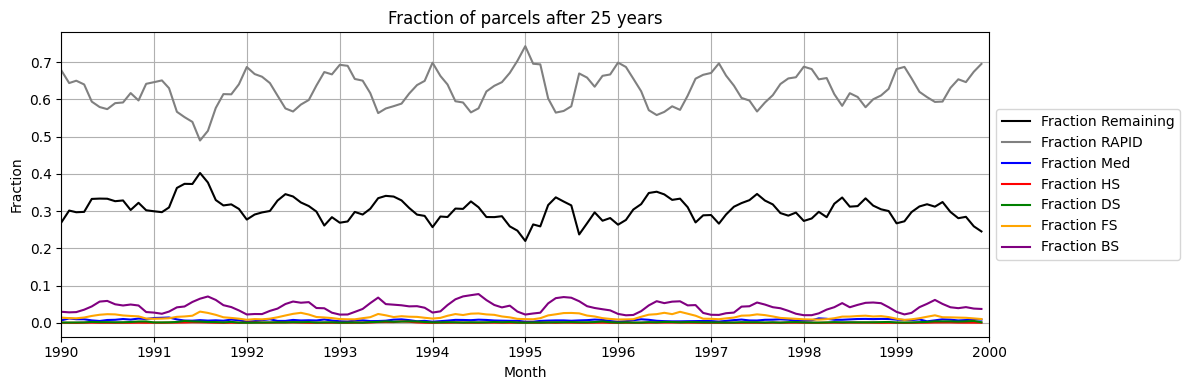

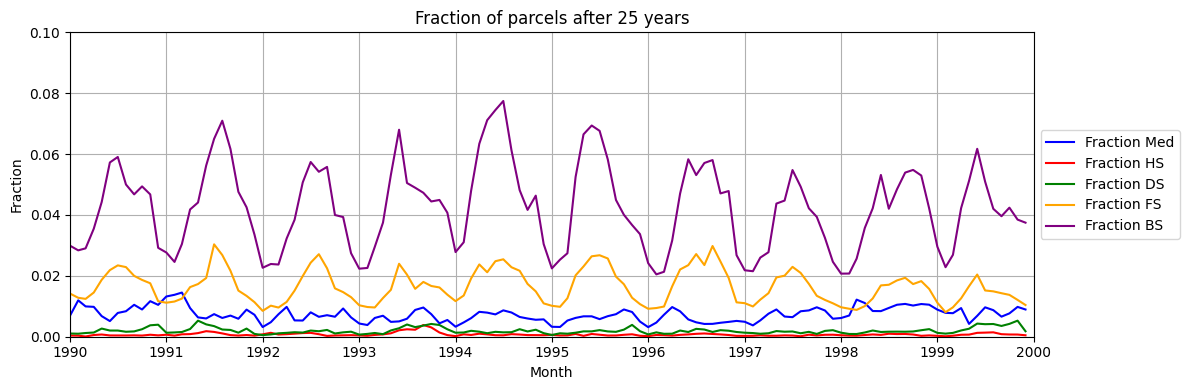

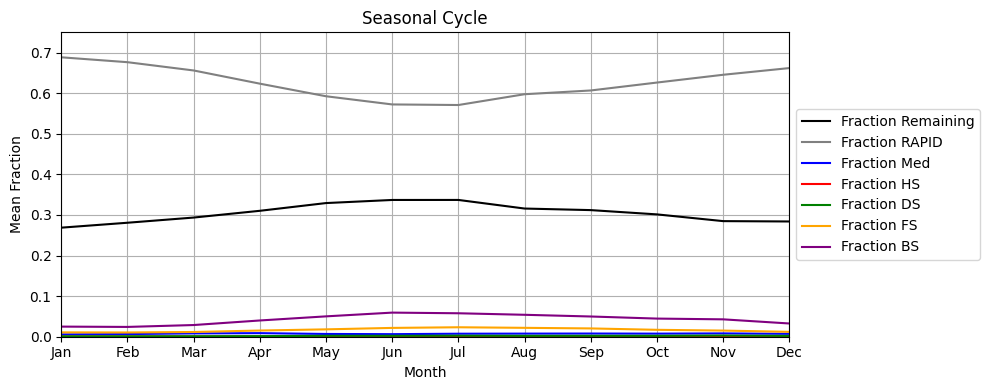

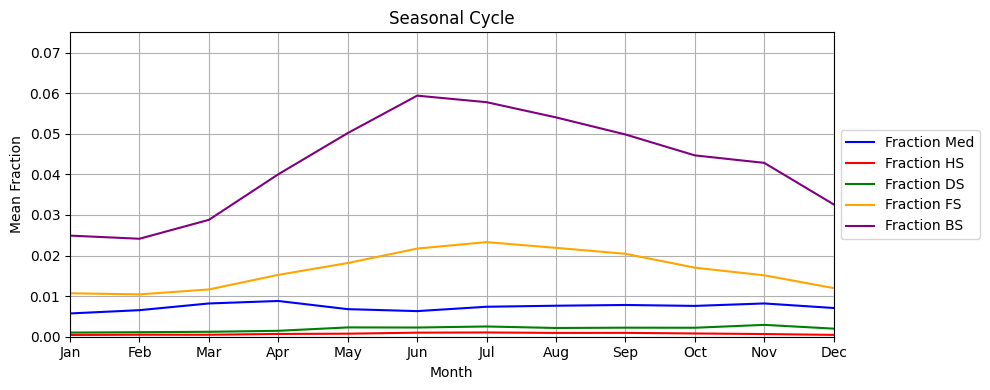

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df_remaining = pd.DataFrame([
    {
        "month": month_key,
        "fraction_remaining": counts["Fraction Remaining"],
        "fraction_RAPID": counts["Fraction RAPID"],
        "fraction_med": counts["Fraction Med"],
        "fraction_HS": counts["Fraction HS"],
        "fraction_DS": counts["Fraction DS"],
        "fraction_FS": counts["Fraction FS"],
        "fraction_BS": counts["Fraction BS"]
    }
    for month_key, counts in all_counts.items()
])

# Convert month strings to datetime for plotting
df_remaining["month_dt"] = pd.to_datetime(df_remaining["month"], format="%Y_%m")

# Sort by datetime
df_remaining = df_remaining.sort_values("month_dt")

# List of fraction columns
fraction_cols = [
    "fraction_remaining",
    "fraction_RAPID",
    "fraction_med",
    "fraction_HS",
    "fraction_DS",
    "fraction_FS",
    "fraction_BS"
]

# Loop over columns and print standard deviation
for col in fraction_cols:
    std = df_remaining[col].std()
    print(f"Standard deviation of {col} over all months: {std}")

# Plot fraction remaining over time
plt.figure(figsize=(12,4))
plt.plot(df_remaining["month_dt"], df_remaining["fraction_remaining"], linestyle='-', color='black', label='Fraction Remaining')
plt.plot(df_remaining["month_dt"], df_remaining["fraction_RAPID"], linestyle='-', color='gray', label='Fraction RAPID')
plt.plot(df_remaining["month_dt"], df_remaining["fraction_med"], linestyle='-', color='blue', label='Fraction Med')
plt.plot(df_remaining["month_dt"], df_remaining["fraction_HS"], linestyle='-', color='red', label='Fraction HS')
plt.plot(df_remaining["month_dt"], df_remaining["fraction_DS"], linestyle='-', color='green', label='Fraction DS')
plt.plot(df_remaining["month_dt"], df_remaining["fraction_FS"], linestyle='-', color='orange', label='Fraction FS')
plt.plot(df_remaining["month_dt"], df_remaining["fraction_BS"], linestyle='-', color='purple', label='Fraction BS')
plt.xlim(pd.Timestamp("1990-01-01"), pd.Timestamp("2000-01-01"))
#plt.ylim(0.2, 0.42)
plt.xlabel("Month")
plt.ylabel("Fraction")
plt.title("Fraction of parcels after 25 years")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.grid()
plt.show()


# Plot fraction remaining over time
plt.figure(figsize=(12,4))
#plt.plot(df_remaining["month_dt"], df_remaining["fraction_remaining"], linestyle='-', color='black', label='Fraction Remaining')
#plt.plot(df_remaining["month_dt"], df_remaining["fraction_RAPID"], linestyle='-', color='gray', label='Fraction RAPID')
plt.plot(df_remaining["month_dt"], df_remaining["fraction_med"], linestyle='-', color='blue', label='Fraction Med')
plt.plot(df_remaining["month_dt"], df_remaining["fraction_HS"], linestyle='-', color='red', label='Fraction HS')
plt.plot(df_remaining["month_dt"], df_remaining["fraction_DS"], linestyle='-', color='green', label='Fraction DS')
plt.plot(df_remaining["month_dt"], df_remaining["fraction_FS"], linestyle='-', color='orange', label='Fraction FS')
plt.plot(df_remaining["month_dt"], df_remaining["fraction_BS"], linestyle='-', color='purple', label='Fraction BS')
plt.xlim(pd.Timestamp("1990-01-01"), pd.Timestamp("2000-01-01"))
plt.ylim(0, 0.1)
plt.xlabel("Month")
plt.ylabel("Fraction")
plt.title("Fraction of parcels after 25 years")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.grid()
plt.show()


df_remaining["month_of_year"] = df_remaining["month_dt"].dt.month

df_monthly_mean = df_remaining.groupby("month_of_year")[fraction_cols].mean().reset_index()

import calendar
df_monthly_mean["month_name"] = df_monthly_mean["month_of_year"].apply(lambda x: calendar.month_abbr[x])

plt.figure(figsize=(10,4))

plt.plot(df_monthly_mean["month_of_year"], df_monthly_mean["fraction_remaining"], color='black', label='Fraction Remaining')
plt.plot(df_monthly_mean["month_of_year"], df_monthly_mean["fraction_RAPID"], color='gray', label='Fraction RAPID')
plt.plot(df_monthly_mean["month_of_year"], df_monthly_mean["fraction_med"], color='blue', label='Fraction Med')
plt.plot(df_monthly_mean["month_of_year"], df_monthly_mean["fraction_HS"], color='red', label='Fraction HS')
plt.plot(df_monthly_mean["month_of_year"], df_monthly_mean["fraction_DS"], color='green', label='Fraction DS')
plt.plot(df_monthly_mean["month_of_year"], df_monthly_mean["fraction_FS"], color='orange', label='Fraction FS')
plt.plot(df_monthly_mean["month_of_year"], df_monthly_mean["fraction_BS"], color='purple', label='Fraction BS')

plt.xticks(range(1,13), df_monthly_mean["month_name"])
plt.xlabel("Month")
plt.ylabel("Mean Fraction")
plt.title("Seasonal Cycle")
plt.ylim(0, 0.75)
plt.xlim(1, 12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,4))

plt.plot(df_monthly_mean["month_of_year"], df_monthly_mean["fraction_med"], color='blue', label='Fraction Med')
plt.plot(df_monthly_mean["month_of_year"], df_monthly_mean["fraction_HS"], color='red', label='Fraction HS')
plt.plot(df_monthly_mean["month_of_year"], df_monthly_mean["fraction_DS"], color='green', label='Fraction DS')
plt.plot(df_monthly_mean["month_of_year"], df_monthly_mean["fraction_FS"], color='orange', label='Fraction FS')
plt.plot(df_monthly_mean["month_of_year"], df_monthly_mean["fraction_BS"], color='purple', label='Fraction BS')

plt.xticks(range(1,13), df_monthly_mean["month_name"])
plt.xlabel("Month")
plt.ylabel("Mean Fraction")
plt.title("Seasonal Cycle")
plt.ylim(0, 0.075)
plt.xlim(1, 12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
# Total trajectories over all months/years
grand_total = sum(month_counts["Total"] for month_counts in all_counts.values())
print("Total trajectories (1990-1999):", grand_total)

# Optional: total remaining over all months/years
total_remaining = sum(month_counts["Remaining"] for month_counts in all_counts.values())
print("Total remaining trajectories after 25 years:", total_remaining)

# Optional: overall fraction remaining
overall_fraction_remaining = total_remaining / grand_total
print("Overall fraction remaining after 25 years:", overall_fraction_remaining)

# Optional: total remaining over all months/years
total_rapid = sum(month_counts["RAPID"] for month_counts in all_counts.values())
print("RAPID:", total_rapid)

# Optional: overall fraction remaining
overall_fraction_rapid = total_rapid / grand_total
print("Overall fraction RAPID:", overall_fraction_rapid)

# Optional: total remaining over all months/years
total_med = sum(month_counts["Med"] for month_counts in all_counts.values())
print("Med:", total_med)

# Optional: overall fraction remaining
overall_fraction_med = total_med / grand_total
print("Overall fraction Med:", overall_fraction_med)

# Optional: total remaining over all months/years
total_HS = sum(month_counts["HS"] for month_counts in all_counts.values())
print("HS:", total_HS)

# Optional: overall fraction remaining
overall_fraction_HS = total_HS / grand_total
print("Overall fraction HS:", overall_fraction_HS)

# Optional: total remaining over all months/years
total_DS = sum(month_counts["DS"] for month_counts in all_counts.values())
print("DS:", total_DS)

# Optional: overall fraction remaining
overall_fraction_DS = total_DS / grand_total
print("Overall fraction DS:", overall_fraction_DS)

# Optional: total remaining over all months/years
total_FS = sum(month_counts["FS"] for month_counts in all_counts.values())
print("FS:", total_FS)

# Optional: overall fraction remaining
overall_fraction_FS = total_FS / grand_total
print("Overall fraction FS:", overall_fraction_FS)

# Optional: total remaining over all months/years
total_BS = sum(month_counts["BS"] for month_counts in all_counts.values())
print("BS:", total_BS)

# Optional: overall fraction remaining
overall_fraction_BS = total_BS / grand_total
print("Overall fraction BS:", overall_fraction_BS)

Total trajectories (1990-1999): 3072252
Total remaining trajectories after 25 years: 935421
Overall fraction remaining after 25 years: 0.30447404705082787
RAPID: 1925226
Overall fraction RAPID: 0.6266497670112998
Med: 22660
Overall fraction Med: 0.007375697045685054
HS: 2217
Overall fraction HS: 0.00072162049206901
DS: 6018
Overall fraction DS: 0.0019588236902441597
FS: 50502
Overall fraction FS: 0.01643810468672492
BS: 130208
Overall fraction BS: 0.04238194002314914


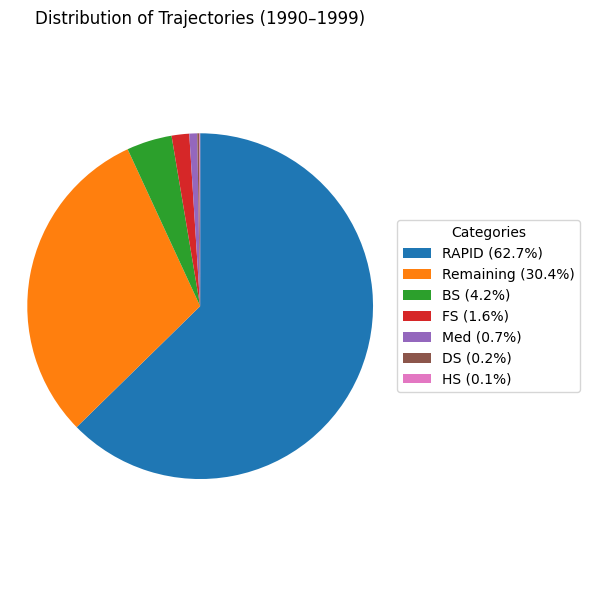

In [36]:
import numpy as np

labels = ["Remaining", "RAPID", "Med", "HS", "DS", "FS", "BS"]

values = np.array([
    total_remaining,
    total_rapid,
    total_med,
    total_HS,
    total_DS,
    total_FS,
    total_BS
])

# Sort indices (descending)
sort_idx = np.argsort(values)[::-1]

# Apply sorting
labels_sorted = [labels[i] for i in sort_idx]
values_sorted = values[sort_idx]

# Percentages
total = values_sorted.sum()
percentages = [(v / total) * 100 for v in values_sorted]

legend_labels = [f"{name} ({p:.1f}%)" for name, p in zip(labels_sorted, percentages)]

plt.figure(figsize=(6,6))

wedges, _ = plt.pie(
    values_sorted,
    startangle=90,
    counterclock=False
)

plt.legend(
    wedges,
    legend_labels,
    title="Categories",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Distribution of Trajectories (1990–1999)")
plt.axis('equal')
plt.tight_layout()
plt.show()